# YSSY 24-Hour Wind Forecast — Full Pipeline

**Workflow:** `FinalData/*.txt` → Parquet → XGBoost → Visual display

**Goal:** For any given time *t*, predict wind (U and V components) at Sydney Airport (YSSY)
for every 30-min step from *t+1* to *t+48* (the next 24 hours).

**Architecture:** One individual `XGBRegressor` per forecast target
(48 steps × 2 components = **96 models** total).

---

### Stations

| ID | Location |
|---|---|
| YSSY | Sydney Airport *(target)* |
| YSCN | Canberra |
| YSNW | Nowra |
| YBTH | Bathurst |
| YCNK | Cessnock |
| YSBK | Bankstown |
| YSRI | Richmond |
| YSWG | Wagga Wagga |
| BELL | Bellambi |
| MTB | Mount Boyce |


## 0 — Imports & Configuration

In [7]:
import os, warnings, random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import joblib
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

print(f'XGBoost version : {xgb.__version__}')
print(f'CUDA available  : {xgb.build_info().get("USE_CUDA", "unknown")}')

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_FOLDER  = Path('/home/jovyan/data/weather/YSSY-Winds/Techlauncher/FinalData')
PARQUET_FILE = Path('/home/jovyan/Techlauncher/weather_data.parquet')
MODELS_DIR   = Path('/home/jovyan/Techlauncher/models')
PLOTS_DIR    = Path('/home/jovyan/Techlauncher/forecast_plots')
PLOTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# ── Stations ───────────────────────────────────────────────────────────────
STATIONS             = ['BELL','MTB','YBTH','YCNK','YSBK','YSCN','YSNW','YSRI','YSSY','YSWG']
STATIONS_NO_PRESSURE = ['BELL', 'MTB']
TARGET_STATION       = 'YSSY'

# ── Time settings ──────────────────────────────────────────────────────────
TIMESTEP_MIN    = 30
LOOKBACK_STEPS  = 48    # 24 hrs of history
FORECAST_STEPS  = 48    # 24 hrs ahead

# ── Train / val / test split ───────────────────────────────────────────────
TRAIN_END_DATE = pd.Timestamp('2018-12-31 23:30')   # 2000-2018  76%
VAL_END_DATE   = pd.Timestamp('2021-12-31 23:30')   # 2019-2021  12%
                                                     # 2022-2024  12% test

# ── XGBoost hyperparameters ────────────────────────────────────────────────
XGB_PARAMS = {
    'objective':          'reg:squarederror',
    'learning_rate':      0.05,
    'max_depth':          6,       # was 10 — biggest memory saving
    'n_estimators':       1000,
    'subsample':          0.7,
    'colsample_bytree':   0.5,     # was 0.7 — uses fewer features per tree = less memory
    'reg_alpha':          0.5,
    'reg_lambda':         0.1,
    'random_state':       42,
    'n_jobs':             -1,
    'device':             'cuda',
    'tree_method':        'hist',
    'early_stopping_rounds': 50,
    'eval_metric':        'rmse',
    'max_bin':            128,     # was default 256 — halves histogram memory
}


QUICK_RUN = False   # set True for a fast smoke-test (~5 min)
SUBSAMPLE  = 0.10

print('\nConfiguration ready.')


XGBoost version : 3.2.0
CUDA available  : True

Configuration ready.


In [8]:
import shutil
shutil.rmtree('models')
print('Cleared — ready to retrain')

Cleared — ready to retrain


---
## 1 — Data Preparation → Parquet

Load every station `.txt` file, apply minimal cleaning, and save one Parquet file.

**File format:**
```
timestamp, air_temp, dew_point, msl_pressure, u_component, v_component
```
Wind is already in U/V form — no conversion needed.

**Steps:**
1. Parse timestamps, coerce numeric columns
2. Fill isolated single-step (30 min) NaN gaps with the average of the two neighbours
3. Align all stations to a shared 30-min timestamp grid
4. Save to Parquet


In [2]:
if PARQUET_FILE.exists():
    print(f'Parquet already exists — skipping data prep.')
    print(f'Delete {PARQUET_FILE} to reprocess from scratch.')
else:
    print('Parquet not found — running data prep...')

    def fill_single_step_gaps(s: pd.Series) -> pd.Series:
        prev_val  = s.shift(1)
        next_val  = s.shift(-1)
        is_single = s.isna() & prev_val.notna() & next_val.notna()
        return s.where(~is_single, (prev_val + next_val) / 2)

    def uv_to_speed_dir(u, v):
        u, v = np.asarray(u, float), np.asarray(v, float)
        speed = np.sqrt(u**2 + v**2)
        direction = (270 - np.degrees(np.arctan2(-v, -u))) % 360
        direction[speed < 0.1] = np.nan
        return speed, direction

    FILE_COLS = ['air_temp', 'dew_point', 'msl_pressure', 'u_component', 'v_component']

    def load_station(station: str) -> pd.DataFrame:
        path = DATA_FOLDER / f'{station}.txt'
        df = pd.read_csv(path, parse_dates=['timestamp'], index_col='timestamp',
                         na_values=['NaN', ''])
        cols = [c for c in FILE_COLS if c in df.columns]
        df = df[cols].copy()
        if station in STATIONS_NO_PRESSURE:
            df.drop(columns=[c for c in ['msl_pressure'] if c in df.columns], inplace=True)
        for col in df.select_dtypes(include='number').columns:
            df[col] = fill_single_step_gaps(df[col])
        df.columns = [f'{station}_{c}' for c in df.columns]
        return df

    print('Loading stations...')
    frames = []
    for sta in STATIONS:
        try:
            frames.append(load_station(sta))
            print(f'  ✓ {sta}')
        except FileNotFoundError:
            print(f'  ✗ {sta}  — file not found, skipping')

    combined = pd.concat(frames, axis=1, join='outer').sort_index()
    full_range = pd.date_range(combined.index.min(), combined.index.max(),
                               freq=f'{TIMESTEP_MIN}min')
    combined = combined.reindex(full_range)

    print(f'\nShape : {combined.shape}')
    print(f'Dates : {combined.index[0]}  →  {combined.index[-1]}')

    combined.to_parquet(PARQUET_FILE)
    print(f'Saved → {PARQUET_FILE}  ({PARQUET_FILE.stat().st_size/1e6:.1f} MB)')

Loading stations...
  ✓ BELL
  ✓ MTB
  ✓ YBTH
  ✓ YCNK
  ✓ YSBK
  ✓ YSCN
  ✓ YSNW
  ✓ YSRI
  ✓ YSSY
  ✓ YSWG

Shape : (438336, 48)
Dates : 2000-01-01 00:00:00  →  2024-12-31 23:30:00
Saved → /home/jovyan/Techlauncher/weather_data.parquet  (32.5 MB)


---
## 2 — Load Parquet & Engineer Features

From here on the notebook reads **only from the Parquet file**.

| Feature group | Description |
|---|---|
| Raw lags | Past 24 hrs at YSSY (all 48 steps); past 6 hrs at other stations (every step), then every other step to 24 hr |
| Pressure gradients | YBTH−YSSY, YSSY−YCNK, YSSY−YSNW at *t*, *t−6 hr*, *t−12 hr* + 6-hr trend |
| Derivatives | 3-hr change in temp, dewpoint, pressure across 8 × 3-hr windows |
| Cyclical time | sin/cos of time-of-day and day-of-year |

**Targets:** `YSSY_u_forecast_t_plus_1` … `YSSY_u_forecast_t_plus_48`
and `YSSY_v_forecast_t_plus_1` … `YSSY_v_forecast_t_plus_48`


In [3]:
df = pd.read_parquet(PARQUET_FILE)
print(f'Loaded from Parquet — {df.shape[0]:,} rows × {df.shape[1]} columns')

def get_features_for_station(station):
    base = ['air_temp','dew_point','msl_pressure','u_component','v_component']
    if station in STATIONS_NO_PRESSURE:
        base = [f for f in base if f != 'msl_pressure']
    return [f'{station}_{f}' for f in base if f'{station}_{f}' in df.columns]

print('Engineering features...')
feat = pd.DataFrame(index=df.index)

# 1. Lagged values
for station in STATIONS:
    for fc in get_features_for_station(station):
        if station == TARGET_STATION:
            for lag in range(LOOKBACK_STEPS):
                feat[f'{fc}_lag{lag}'] = df[fc].shift(lag)
        else:
            for lag in list(range(12)) + list(range(12, LOOKBACK_STEPS, 2)):
                feat[f'{fc}_lag{lag}'] = df[fc].shift(lag)

# 2. Pressure gradients
PG_PAIRS   = [('YBTH','YSSY'), ('YSSY','YCNK'), ('YSSY','YSNW')]
PG_OFFSETS = {'t': 0, 't_minus_6hr': 12, 't_minus_12hr': 24}
for s1, s2 in PG_PAIRS:
    c1, c2 = f'{s1}_msl_pressure', f'{s2}_msl_pressure'
    if c1 not in df or c2 not in df:
        continue
    label = f'PG_{s1}_{s2}'
    for tl, off in PG_OFFSETS.items():
        feat[f'{label}_{tl}'] = df[c1].shift(off) - df[c2].shift(off)
    feat[f'{label}_trend_6hr']  = feat[f'{label}_t'] - feat[f'{label}_t_minus_6hr']
    feat[f'{label}_trend_12hr'] = feat[f'{label}_t'] - feat[f'{label}_t_minus_12hr']

# 3. 3-hr derivatives
DERIV_PARAMS  = ['air_temp','dew_point','msl_pressure']
STEPS_PER_3HR = int(3 * 60 / TIMESTEP_MIN)
for station in STATIONS:
    for param in DERIV_PARAMS:
        c = f'{station}_{param}'
        if c not in df.columns:
            continue
        for period in range(8):
            end_lag   = period * STEPS_PER_3HR
            start_lag = (period + 1) * STEPS_PER_3HR
            if start_lag > LOOKBACK_STEPS:
                continue
            feat[f'{c}_deriv_{end_lag*TIMESTEP_MIN}min_vs_{start_lag*TIMESTEP_MIN}min'] = (
                df[c].shift(end_lag) - df[c].shift(start_lag)
            )

# 4. Cyclical time features
half_hr    = df.index.hour * 2 + df.index.minute // 30
days_in_yr = np.where(df.index.is_leap_year, 366, 365)
feat['sin_time_of_day']  = np.sin(2 * np.pi * half_hr / 48)
feat['cos_time_of_day']  = np.cos(2 * np.pi * half_hr / 48)
feat['sin_day_of_year']  = np.sin(2 * np.pi * df.index.dayofyear / days_in_yr)
feat['cos_day_of_year']  = np.cos(2 * np.pi * df.index.dayofyear / days_in_yr)

# 5. Targets
target_cols = []
for step in range(1, FORECAST_STEPS + 1):
    for comp in ['u_component', 'v_component']:
        tname = f'YSSY_{comp[0]}_forecast_t_plus_{step}'
        feat[tname] = df[f'{TARGET_STATION}_{comp}'].shift(-step)
        target_cols.append(tname)

feat.dropna(inplace=True)
FEATURE_COLS = [c for c in feat.columns if c not in target_cols]

print(f'Samples  : {len(feat):,}')
print(f'Features : {len(FEATURE_COLS):,}')
print(f'Targets  : {len(target_cols)}  (u+v × {FORECAST_STEPS} steps)')


Loaded from Parquet — 438,336 rows × 48 columns
Engineering features...
Samples  : 388,052
Features : 1,773
Targets  : 96  (u+v × 48 steps)


---
## 3 — Train / Validation / Test Split

Chronological split — no shuffling.


In [4]:
X = feat[FEATURE_COLS]
Y = feat[target_cols]

train_mask = feat.index <= TRAIN_END_DATE
val_mask   = (feat.index > TRAIN_END_DATE) & (feat.index <= VAL_END_DATE)
test_mask  = feat.index > VAL_END_DATE

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

for name, Xs in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'{name:6s}: {len(Xs):>7,} samples  '
          f'({Xs.index[0].date()} → {Xs.index[-1].date()})')


Train : 290,496 samples  (2000-01-02 → 2018-12-29)
Val   :  49,212 samples  (2019-01-03 → 2021-12-31)
Test  :  48,344 samples  (2022-01-01 → 2024-12-30)


---
## 4 — Train Individual XGBoost Models

One `XGBRegressor` per forecast target (96 models total) using the NVIDIA L4 GPU.

Models are saved to `models/u_models/` and `models/v_models/` —
rerunning this cell skips any model that already exists on disk.

> Set `QUICK_RUN = True` in the config cell for a fast end-to-end test on 10% of data.


In [5]:
import xgboost as xgb
import numpy as np

# Quick smoke test on the GPU
X_dummy = np.random.rand(100, 10)
y_dummy = np.random.rand(100)

model = xgb.XGBRegressor(device='cuda', tree_method='hist', n_estimators=10, verbosity=1)
model.fit(X_dummy, y_dummy)
print('✓ GPU training confirmed')

✓ GPU training confirmed


In [9]:
if QUICK_RUN:
    idx = X_train.sample(frac=SUBSAMPLE, random_state=42).index
    X_tr, Y_tr = X_train.loc[idx], Y_train.loc[idx]
    print(f'QUICK_RUN: {len(X_tr):,} / {len(X_train):,} training samples')
else:
    X_tr, Y_tr = X_train, Y_train
    print(f'Full training run: {len(X_tr):,} samples')

total_start    = time.time()
trained_models = {}

for step in range(1, FORECAST_STEPS + 1):
    for comp in ['u', 'v']:
        target_name = f'YSSY_{comp}_forecast_t_plus_{step}'
        model_path  = MODELS_DIR / f'{comp}_models' / f'{target_name}.joblib'
        model_path.parent.mkdir(parents=True, exist_ok=True)

        if model_path.exists():
            trained_models[target_name] = joblib.load(model_path)
            continue

        model = xgb.XGBRegressor(**XGB_PARAMS)
        model.fit(
            X_tr, Y_tr[target_name],
            eval_set=[(X_val, Y_val[target_name])],
            verbose=500
        )
        joblib.dump(model, model_path)
        trained_models[target_name] = model

    if step % 12 == 0 or step == FORECAST_STEPS:
        elapsed = (time.time() - total_start) / 60
        print(f'  Step {step:2d}/48 done  ({elapsed:.1f} min elapsed)')

print(f'\n✓ {len(trained_models)} models ready.')


Full training run: 290,496 samples
[0]	validation_0-rmse:7.37377
[500]	validation_0-rmse:2.39366
[999]	validation_0-rmse:2.38097
[0]	validation_0-rmse:8.83853
[500]	validation_0-rmse:2.45859
[999]	validation_0-rmse:2.45062
[0]	validation_0-rmse:7.40000
[500]	validation_0-rmse:2.84301
[999]	validation_0-rmse:2.82870
[0]	validation_0-rmse:8.85445
[500]	validation_0-rmse:2.93184
[999]	validation_0-rmse:2.91801
[0]	validation_0-rmse:7.41820
[500]	validation_0-rmse:3.12230
[639]	validation_0-rmse:3.11793
[0]	validation_0-rmse:8.86425
[500]	validation_0-rmse:3.23112
[732]	validation_0-rmse:3.22314
[0]	validation_0-rmse:7.43481
[500]	validation_0-rmse:3.32339
[999]	validation_0-rmse:3.30739
[0]	validation_0-rmse:8.87349
[500]	validation_0-rmse:3.46229
[999]	validation_0-rmse:3.44535
[0]	validation_0-rmse:7.44841
[500]	validation_0-rmse:3.49629
[999]	validation_0-rmse:3.47517
[0]	validation_0-rmse:8.88336
[500]	validation_0-rmse:3.66648
[999]	validation_0-rmse:3.64728
[0]	validation_0-rmse:7.4

---
## 5 — Evaluate: Error vs Lead Time

MAE and MSE per forecast step for U and V components.
A well-trained model shows error growing steadily with lead time.


Lead(hr)  MAE_u   MAE_v   MAE_avg
 lead_hr  mae_u  mae_v  mae_avg
   0.500  1.742  1.760    1.751
   3.500  2.816  3.001    2.909
   6.500  3.242  3.673    3.457
   9.500  3.504  4.217    3.861
  12.500  3.707  4.703    4.205
  15.500  3.845  5.093    4.469
  18.500  3.938  5.429    4.684
  21.500  4.040  5.686    4.863


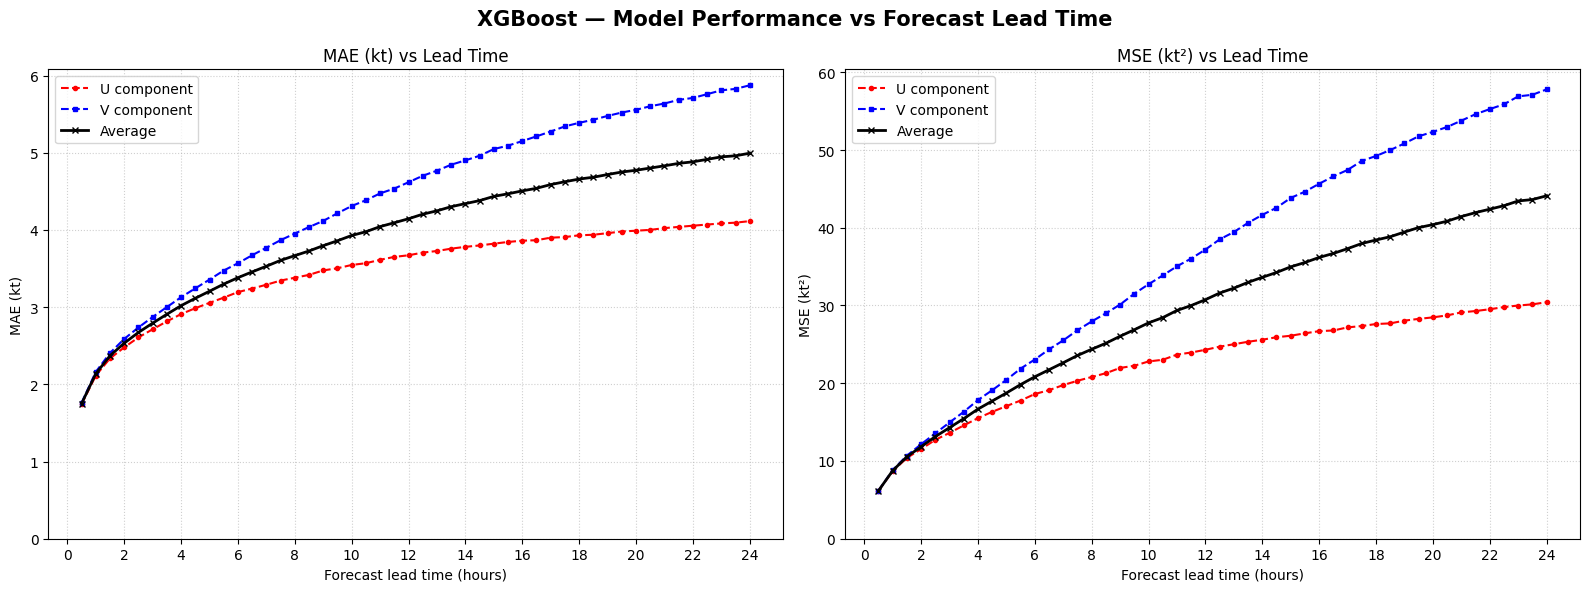

Saved → performance_vs_lead_time.png


In [10]:
metrics = []
for step in range(1, FORECAST_STEPS + 1):
    row = {'lead_hr': step * 0.5}
    for comp in ['u', 'v']:
        tname  = f'YSSY_{comp}_forecast_t_plus_{step}'
        pred   = trained_models[tname].predict(X_test)
        actual = Y_test[tname].values
        row[f'mae_{comp}'] = mean_absolute_error(actual, pred)
        row[f'mse_{comp}'] = mean_squared_error(actual, pred)
    row['mae_avg'] = (row['mae_u'] + row['mae_v']) / 2
    row['mse_avg'] = (row['mse_u'] + row['mse_v']) / 2
    metrics.append(row)

metrics_df = pd.DataFrame(metrics)

print('Lead(hr)  MAE_u   MAE_v   MAE_avg')
print(metrics_df[['lead_hr','mae_u','mae_v','mae_avg']]
      .iloc[::6].to_string(index=False, float_format='%.3f'))

# ── Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost — Model Performance vs Forecast Lead Time',
             fontsize=15, fontweight='bold')

for ax, metric, title in [(ax1, 'mae', 'MAE (kt)'), (ax2, 'mse', 'MSE (kt²)')]:
    ax.plot(metrics_df.lead_hr, metrics_df[f'{metric}_u'],
            'r--', marker='o', ms=3, label='U component')
    ax.plot(metrics_df.lead_hr, metrics_df[f'{metric}_v'],
            'b--', marker='s', ms=3, label='V component')
    ax.plot(metrics_df.lead_hr, metrics_df[f'{metric}_avg'],
            'k-',  marker='x', ms=4, lw=2, label='Average')
    ax.set_xlabel('Forecast lead time (hours)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Lead Time')
    ax.set_xticks(range(0, 25, 2))
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_vs_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → performance_vs_lead_time.png')


---
## 6 — Visual Display: Forecast vs Observed

For a chosen anchor time *t*:
- **Red line** — observed temperature
- **Blue line** — observed dewpoint
- **Grey line** — observed wind speed
- **Thick black line** — model's 24-hr wind speed forecast
- **Grey circles** — observed wind direction (right axis)
- **Black crosses** — forecast wind direction (right axis)
- **Dotted vertical line** — forecast anchor time *t*


In [11]:
def predict_24hr(anchor_idx: int) -> tuple:
    """Return predicted U and V arrays (length 48) for a row in X_test."""
    row = X_test.iloc[[anchor_idx]]
    pred_u = np.array([trained_models[f'YSSY_u_forecast_t_plus_{s}'].predict(row)[0]
                       for s in range(1, FORECAST_STEPS + 1)])
    pred_v = np.array([trained_models[f'YSSY_v_forecast_t_plus_{s}'].predict(row)[0]
                       for s in range(1, FORECAST_STEPS + 1)])
    return pred_u, pred_v


def plot_forecast(anchor_time, pred_u, pred_v, save_path=None):
    window_start  = anchor_time - timedelta(hours=24)
    window_end    = anchor_time + timedelta(hours=24)
    obs           = df.loc[window_start:window_end].copy()
    future_times  = [anchor_time + timedelta(minutes=30*s) for s in range(1, FORECAST_STEPS+1)]

    obs_u  = obs.get(f'{TARGET_STATION}_u_component', pd.Series(dtype=float))
    obs_v  = obs.get(f'{TARGET_STATION}_v_component', pd.Series(dtype=float))
    obs_ws, obs_wd   = uv_to_speed_dir(obs_u.values, obs_v.values)
    pred_ws, pred_wd = uv_to_speed_dir(pred_u, pred_v)

    obs_temp = obs.get(f'{TARGET_STATION}_air_temp',  pd.Series(dtype=float))
    obs_dewp = obs.get(f'{TARGET_STATION}_dew_point', pd.Series(dtype=float))

    fig, ax1 = plt.subplots(figsize=(18, 9))
    fig.suptitle(
        f'YSSY 24-hr Forecast  |  Anchor: {anchor_time.strftime("%Y-%m-%d %H:%M")}',
        fontsize=14, fontweight='bold'
    )

    # Primary axis
    ax1.plot(obs.index, obs_temp.values, 'r-',       lw=1.5, label='Observed Temp (°C)',     zorder=3)
    ax1.plot(obs.index, obs_dewp.values, 'b-',       lw=1.5, label='Observed Dewpoint (°C)', zorder=3)
    ax1.plot(obs.index, obs_ws,    '-',  color='gray', lw=2.5, label='Observed Wind Speed (kt)', zorder=3)
    ax1.plot(future_times, pred_ws, '-', color='black', lw=4,  label='Forecast Wind Speed (kt)', zorder=4)
    ax1.set_ylabel('Temperature (°C) / Wind Speed (kt)')
    ax1.set_ylim(0, 40)
    ax1.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax1.grid(True, linestyle=':', alpha=0.5)

    # Secondary axis — wind direction
    ax2 = ax1.twinx()
    ax2.scatter(obs.index,   obs_wd,  marker='o', c='darkgray', s=35, label='Observed Wind Dir (°)', zorder=5)
    ax2.scatter(future_times, pred_wd, marker='X', c='black',   s=50, label='Forecast Wind Dir (°)', zorder=6)
    ax2.set_ylabel('Wind Direction (° from North)')
    ax2.set_ylim(0, 360)
    ax2.yaxis.set_major_locator(mticker.MultipleLocator(45))

    # Anchor line & x-axis
    ax1.axvline(anchor_time, color='black', linestyle=':', lw=1.2, alpha=0.7)
    ax1.set_xlim(window_start, window_end)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d-%b'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))

    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labs1 + labs2,
               loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    plt.close(fig)

print('Plot function ready — run the next cell to generate forecasts.')


Plot function ready — run the next cell to generate forecasts.



Sample 1/5  —  anchor: 2024-12-23 10:00:00
Saved → /home/jovyan/Techlauncher/forecast_plots/forecast_20241223_1000.png


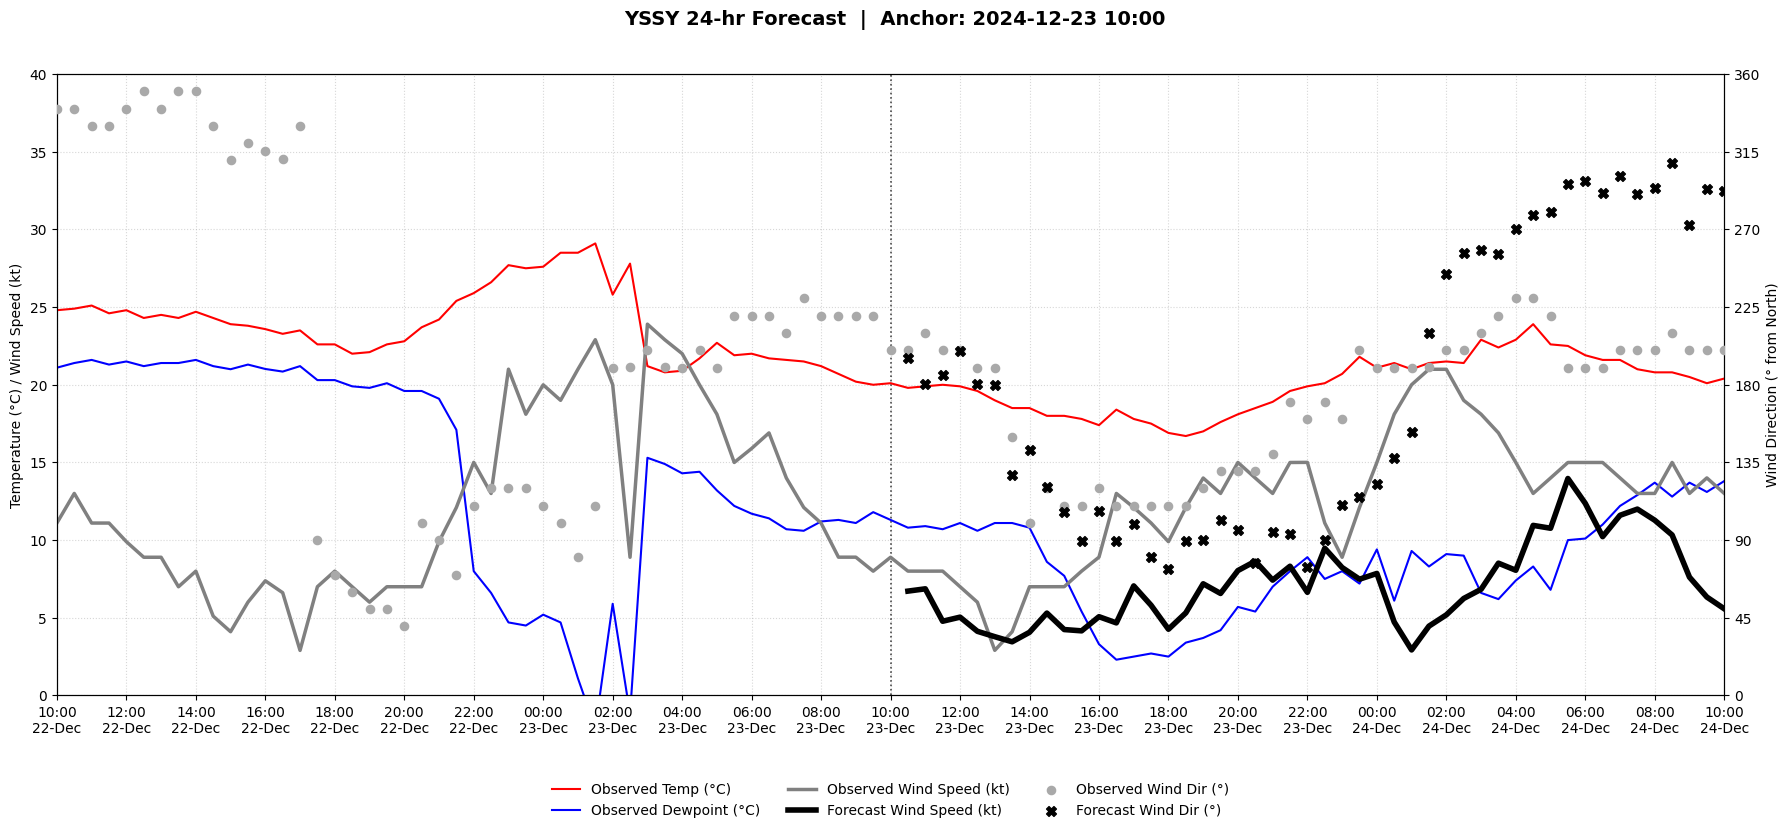


Sample 2/5  —  anchor: 2023-05-20 02:30:00
Saved → /home/jovyan/Techlauncher/forecast_plots/forecast_20230520_0230.png


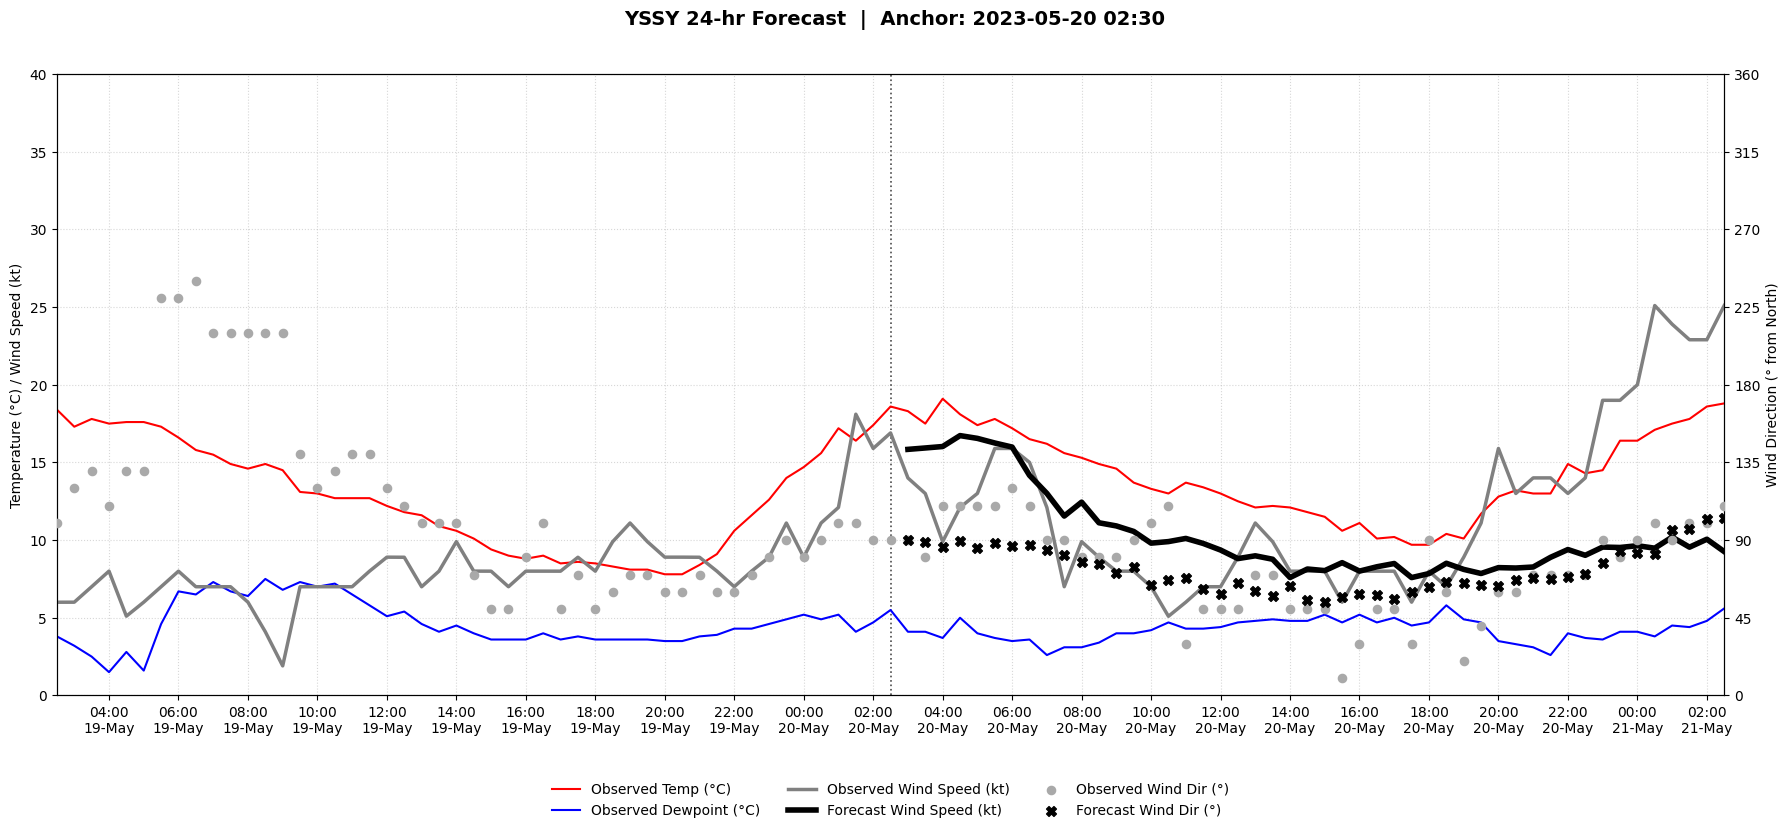


Sample 3/5  —  anchor: 2022-09-25 11:30:00
Saved → /home/jovyan/Techlauncher/forecast_plots/forecast_20220925_1130.png


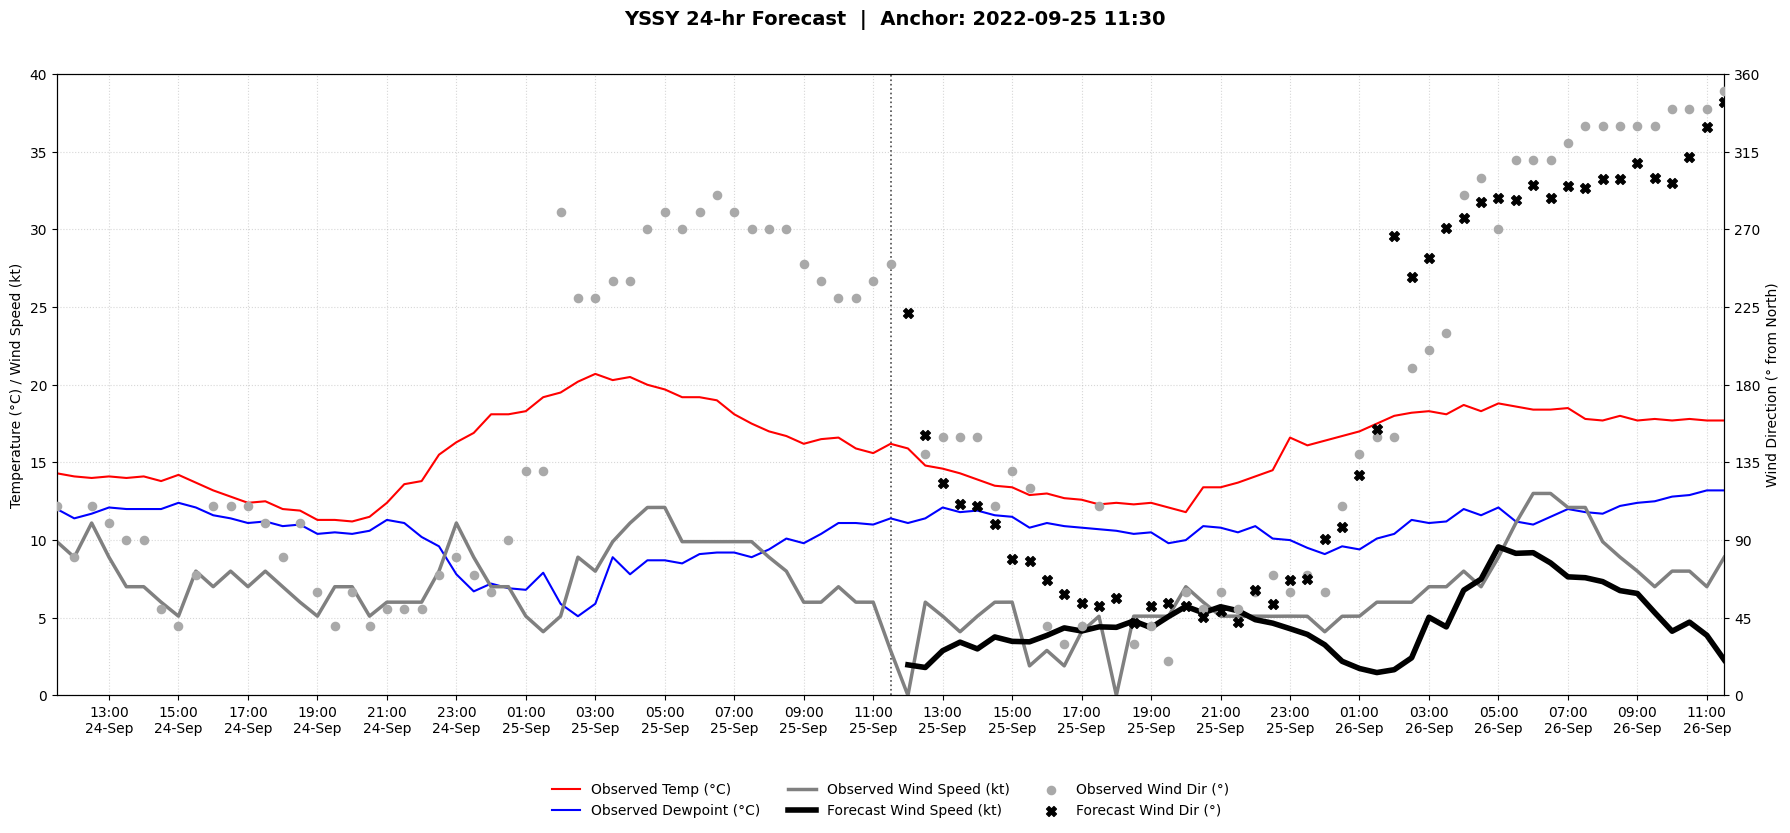


Sample 4/5  —  anchor: 2022-01-09 21:00:00
Saved → /home/jovyan/Techlauncher/forecast_plots/forecast_20220109_2100.png


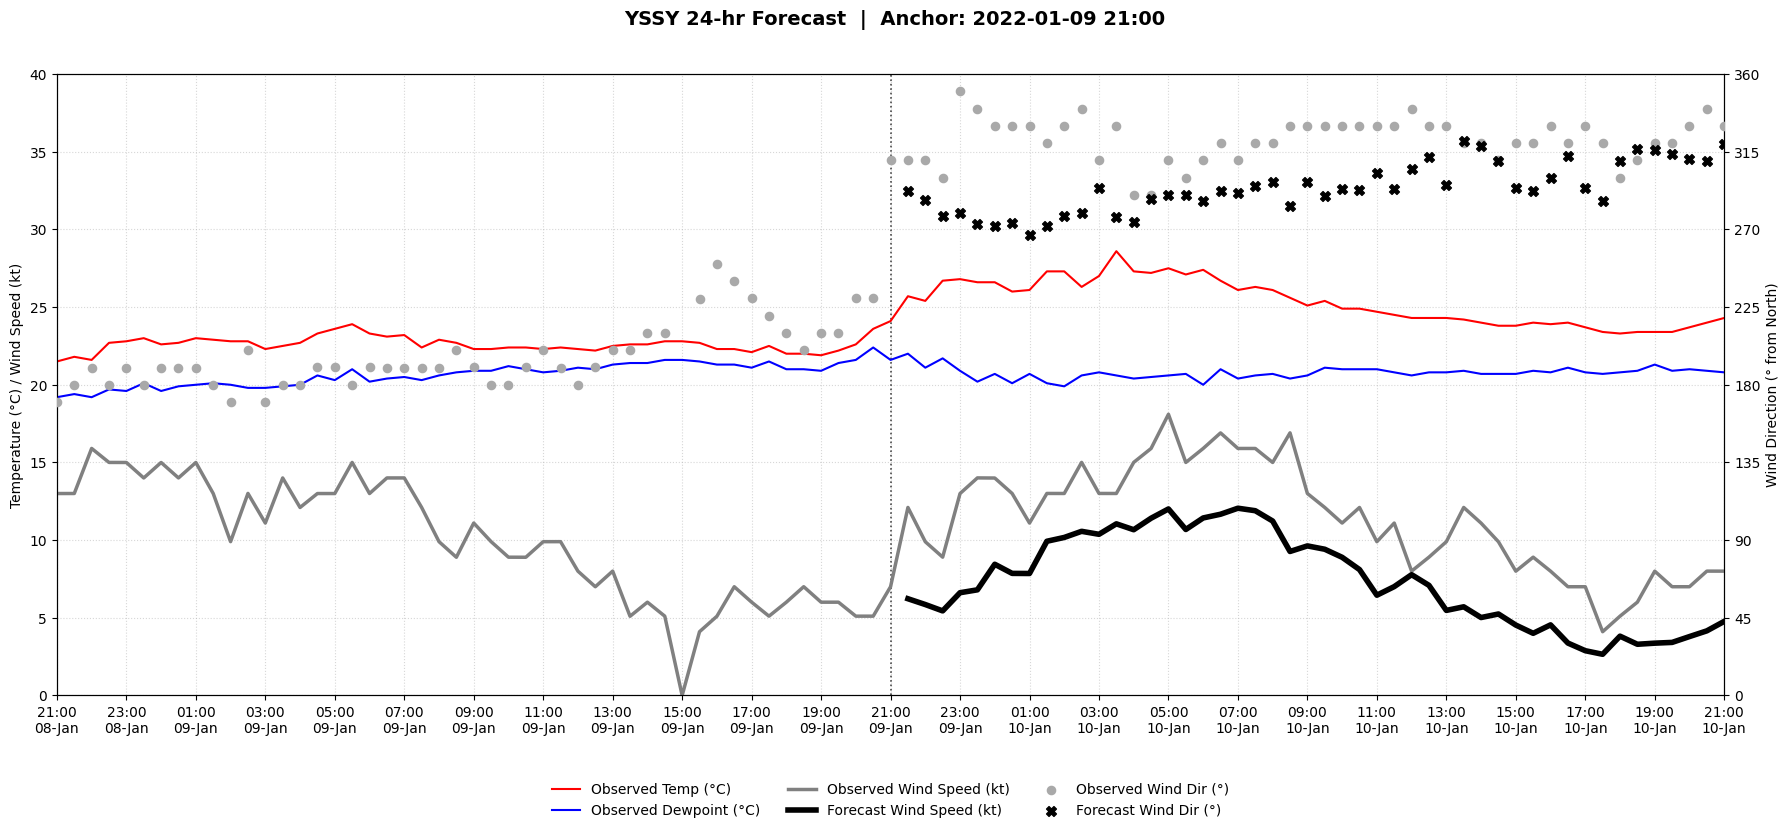


Sample 5/5  —  anchor: 2024-09-25 18:00:00
Saved → /home/jovyan/Techlauncher/forecast_plots/forecast_20240925_1800.png


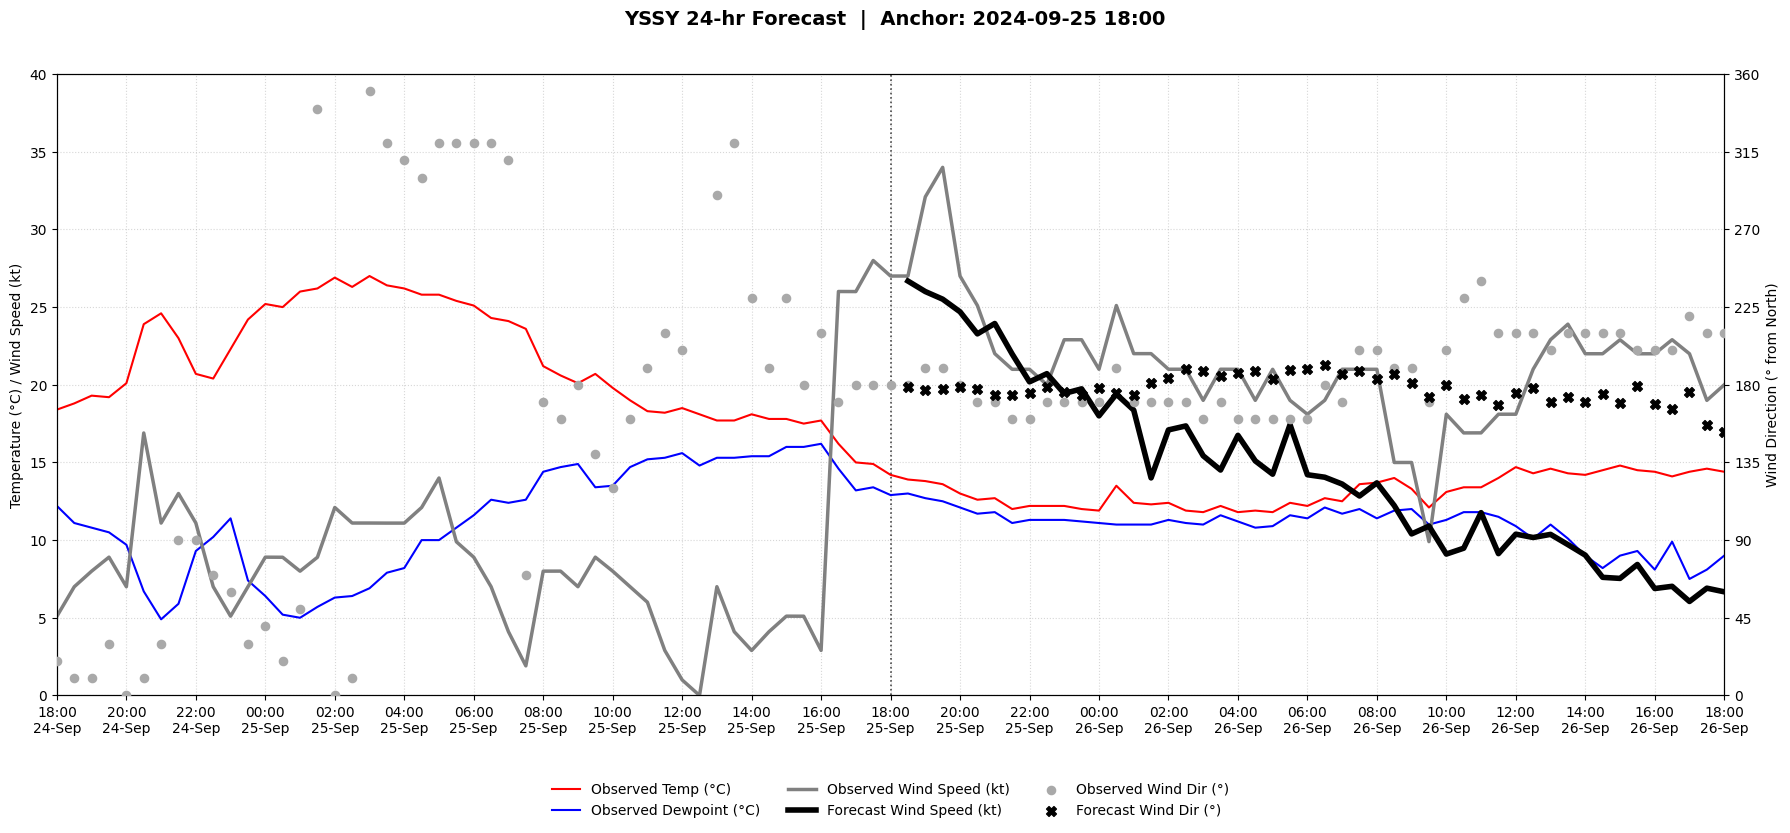


All plots saved to /home/jovyan/Techlauncher/forecast_plots/


In [12]:
NUM_SAMPLE_PLOTS = 5   # increase as needed

test_times     = X_test.index.tolist()
sample_indices = random.sample(range(len(test_times)), min(NUM_SAMPLE_PLOTS, len(test_times)))

for i, idx in enumerate(sample_indices):
    anchor    = test_times[idx]
    pred_u, pred_v = predict_24hr(idx)
    save_path = PLOTS_DIR / f'forecast_{anchor.strftime("%Y%m%d_%H%M")}.png'
    print(f'\nSample {i+1}/{NUM_SAMPLE_PLOTS}  —  anchor: {anchor}')
    plot_forecast(anchor, pred_u, pred_v, save_path=save_path)

print(f'\nAll plots saved to {PLOTS_DIR}/')


---
## 7 — Pipeline Summary

| Step | What it does | Scripts replaced |
|---|---|---|
| **1 — Data → Parquet** | Load `.txt` files, fill 30-min gaps, align grid, save Parquet | `merge_stations.py`, `interpolateData0_5.py`, `convertWindComponents.py`, `crop_to_years.py`, `drop_columns.py` |
| **2 — Features** | Lags, pressure gradients, 3-hr derivatives, cyclical time | `preprocess_data.py` |
| **3 — Split** | Chronological train / val / test | `preprocess_data.py` |
| **4 — Train** | 96 individual XGBRegressors with early stopping on L4 GPU | `YSSY_LightGMB.pyw`, `YSSY_winds_24hr.pyw`, `train_final_individual.pyw` |
| **5 — Evaluate** | MAE / MSE per lead time, error-vs-lead-time plot | `evaluate_all_24hr_models.pyw` |
| **6 — Visualise** | 24-hr observed + forecast wind plot | `plot_test_samples.pyw`, `plot_samples_24hr.pyw` |

**Scripts not included (dead ends / diagnostics):**
- `interpolateTest.py` — spline experimentation
- `find_missing_timestamp.py` — one-off diagnostic
- `outage_lengths.py` — data quality audit
